# 4 — Stage 1: is this sentence an adverse drug event?

A yes/no decision on a whole sentence.

> *"A case of toxic hepatitis caused by methotrexate."* → **ADE**
> *"She was treated with cisplatin, vinblastine and bleomycin."* → **not ADE**

The second one mentions three drugs and is still not an ADE, because nothing bad is
reported. That is the difficulty in one line: this is not keyword spotting.

Eight models were trained, in a deliberate ladder from simplest to most powerful. Four of
them are the **embedding ablation** — the same network, four different starting vectors —
and that is the result the project exists to produce.

In [1]:
import sys, json, textwrap
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
pd.set_option("display.max_colwidth", 90)
print("project root:", ROOT)

project root: E:\CSE\NLP Project


---

## 4.1 The data, and why accuracy is the wrong metric

In [2]:
train = pd.read_parquet(ROOT / "data" / "splits" / "stage1_train.parquet")
test = pd.read_parquet(ROOT / "data" / "splits" / "stage1_test.parquet")

print(f"train {len(train):,} sentences, test {len(test):,} sentences\n")
print(train["label"].value_counts().rename({0: "not ADE", 1: "ADE"}).to_string())
print(f"\npositive rate: {train['label'].mean():.2%}")
print(f"always predicting 'not ADE' would score {1 - test['label'].mean():.1%} accuracy")

train 14,628 sentences, test 3,133 sentences

label
not ADE    11638
ADE         2990

positive rate: 20.44%
always predicting 'not ADE' would score 79.6% accuracy


**79.6% accuracy for a model that has learned nothing.** So accuracy is reported but never
used to choose anything.

The primary metric is **macro-F1**: compute F1 for the ADE class and F1 for the not-ADE
class, then average them with equal weight. A model that ignores the minority class scores
badly on it and the average drops. The dev split selects the model; the test split is
scored once at the end.

---

## 4.2 The model ladder

| Tier | Runs | Model | Idea |
|---|---|---|---|
| T1 | 1 | Multinomial Naive Bayes | word counts, independence assumption |
| T2 | 2, 2b | Logistic Regression, Linear SVM | TF-IDF features, a learned linear boundary |
| T3 | **3-6** | **BiLSTM + attention** | **word order and context — the ablation** |
| T4 | 7 | BERT base | general-purpose transformer, fine-tuned |
| T5 | 8 | BiomedBERT | a transformer pretrained on PubMed |

Each tier tests one idea, and the jump between tiers is the interesting part.

### T1-T2: the sparse baselines

Fast, and they run on a CPU in seconds. They exist so the neural results have a floor to
beat — a BiLSTM below TF-IDF logistic regression means the BiLSTM is undertrained, not
that embeddings do not help.

```python
vectorizer = TfidfVectorizer(tokenizer=lambda t: tokenize(t)[0],   # OUR tokenizer
                             ngram_range=(1, 2), min_df=2, lowercase=False)
X_train = vectorizer.fit_transform(train["text"])      # fitted on train only

model = LogisticRegression(C=C, class_weight="balanced", max_iter=2000)
model.fit(X_train, train["label"])                     # C chosen on dev macro-F1
```

Two details that matter: the vectorizer is fitted on **train only** (fitting on train+test
leaks test vocabulary into the features), and `class_weight="balanced"` is what stops the
1:4 imbalance from producing a model that always says "not ADE".

### T3: the BiLSTM — the model the ablation runs on

```
word ids -> Embedding (E0/E1/E2/E3) -> BiLSTM -> attention -> dropout -> linear -> 2
```

Three design choices worth defending:

- **Bidirectional LSTM.** "The rash resolved after stopping the drug" and "The drug was
  stopped after the rash resolved" contain the same words. Order is the signal.
- **Additive attention instead of mean pooling.** An ADE sentence is usually positive
  because of a short span — *"developed hepatotoxicity"* — buried in a long clinical
  description. Attention can concentrate on a few positions; an average over 18 words
  dilutes them.
- **The embedding matrix is a constructor argument, not built inside.** This is what makes
  runs 3-6 a controlled experiment.

The definition is in `src/models.py` and is built here so you can see its size.

In [3]:
import numpy as np
from src.models import BiLSTMClassifier

matrix = np.load(ROOT / "models" / "emb_matrices" / "E3.npy")
model = BiLSTMClassifier(matrix, num_classes=2, hidden_dim=256, dropout=0.5,
                         freeze_embeddings=True)

print(model)
total = sum(p.numel() for p in model.parameters())
print(f"\nparameters total     : {total:,}")
print(f"of which trainable   : {model.trainable_parameters():,}")
print(f"frozen in the embedding: {total - model.trainable_parameters():,}"
      f"  ({matrix.shape[0]:,} words x {matrix.shape[1]})")

BiLSTMClassifier(
  (embedding): Embedding(12220, 300, padding_idx=0)
  (embed_dropout): Dropout(p=0.5, inplace=False)
  (lstm): LSTM(300, 256, batch_first=True, bidirectional=True)
  (attention): AdditiveAttention(
    (project): Linear(in_features=512, out_features=128, bias=True)
    (score): Linear(in_features=128, out_features=1, bias=False)
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (classifier): Linear(in_features=512, out_features=2, bias=True)
)

parameters total     : 4,875,602
of which trainable   : 1,209,602
frozen in the embedding: 3,666,000  (12,220 words x 300)


`freeze_embeddings=True` is why 3.7M of the 5.4M parameters get no gradient: the run is
measuring **the pretrained vectors themselves**, not what the task can teach them.

### The training loop

Ordinary supervised training, run on a Kaggle GPU. Nothing exotic — which is the point,
since anything exotic would be another variable between the four runs.

```python
set_seed(42)                                    # identical in runs 3, 4, 5 and 6
model = BiLSTMClassifier(np.load(f"models/emb_matrices/{args.embedding}.npy"),
                         hidden_dim=256, dropout=0.5,
                         freeze_embeddings=not args.unfreeze_embeddings)

criterion = nn.CrossEntropyLoss(weight=class_weights(train_labels))  # 1:4 imbalance
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(15):
    for ids, lengths, labels in train_loader:
        loss = criterion(model(ids, lengths), labels)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    dev_f1 = evaluate(model, dev_loader)         # macro-F1 on dev, every epoch
    if dev_f1 > best:
        torch.save({"state_dict": model.state_dict(), "config": model.config,
                    "embedding": args.embedding}, out / "checkpoint.pt")
    elif epochs_without_improvement >= 3:        # early stopping
        break
```

The only thing that changes between runs 3, 4, 5 and 6 is `--embedding E0_random | E1 | E2 | E3`.

### T4-T5: the transformers

```python
model = AutoModelForSequenceClassification.from_pretrained(name, num_labels=2)

# run 7: "bert-base-uncased"                       - general English
# run 8: "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract"  - pretrained on PubMed
```

Fine-tuned with the Hugging Face `Trainer` for 3 epochs at learning rate 2e-5, effective
batch 16, max length 128. Run 8 is the same recipe as run 7 with a different checkpoint —
so the difference between them is *pretraining domain*, the same question the E1-vs-E2/E3
ablation asks, at a different scale.

---

## 4.3 Results

Every run appended one row to `results/runs.csv` when it finished — score, hyperparameters,
git commit, seed. Nothing below is typed by hand; the table is read straight from that log.

In [4]:
runs = pd.read_csv(ROOT / "results" / "runs.csv")
stage1 = runs[runs["stage"].astype(str) == "1"].drop_duplicates("run_id", keep="last")

TIERS = {"1": "T1 counts", "2": "T2 linear", "2b": "T2 linear",
         "3": "T3 BiLSTM", "4": "T3 BiLSTM", "5": "T3 BiLSTM", "6": "T3 BiLSTM",
         "3u": "T3 BiLSTM", "4u": "T3 BiLSTM", "5u": "T3 BiLSTM", "6u": "T3 BiLSTM",
         "7": "T4 BERT", "8": "T5 BiomedBERT"}

table = pd.DataFrame({
    "run": stage1["run_id"],
    "tier": stage1["run_id"].map(TIERS),
    "model": stage1["model"],
    "embedding": stage1["embedding"].str.replace("microsoft/BiomedNLP-", "", regex=False),
    "macro-F1 (test)": stage1["macro_f1"].round(4),
}).set_index("run")
table.loc[[r for r in ["1", "2", "2b", "3", "4", "5", "6", "7", "8"] if r in table.index]]

,tier,model,embedding,macro-F1 (test)
run,,,,
1,T1 counts,naive_bayes,count-1-2gram,0.7678
2,T2 linear,logreg,tfidf-1-2gram,0.7934
2b,T2 linear,linear_svm,tfidf-1-2gram,0.7977
3,T3 BiLSTM,bilstm_attn,E0_random,0.7441
4,T3 BiLSTM,bilstm_attn,E1,0.7942
5,T3 BiLSTM,bilstm_attn,E2,0.8609
6,T3 BiLSTM,bilstm_attn,E3,0.8785
7,T4 BERT,bert-base-uncased,bert-base-uncased,0.9159
8,T5 BiomedBERT,biomedbert,BiomedBERT-base-uncased-abstract,0.9402


### The headline: runs 3, 4, 5, 6

Same architecture. Same hyperparameters. Same seed. Same split. **The embedding matrix is
the only thing that changed.**

In [5]:
ablation = table.loc[["3", "4", "5", "6"]].copy()
ablation["what it is"] = ["random (floor)", "GloVe, general English",
                          "Word2Vec, our PubMed corpus", "FastText, our PubMed corpus"]
floor = ablation.loc["3", "macro-F1 (test)"]
ablation["gain over random"] = (ablation["macro-F1 (test)"] - floor).round(4)
ablation[["embedding", "what it is", "macro-F1 (test)", "gain over random"]]

,embedding,what it is,macro-F1 (test),gain over random
run,,,,
3,E0_random,random (floor),0.7441,0.0000
4,E1,"GloVe, general English",0.7942,0.0501
5,E2,"Word2Vec, our PubMed corpus",0.8609,0.1168
6,E3,"FastText, our PubMed corpus",0.8785,0.1344


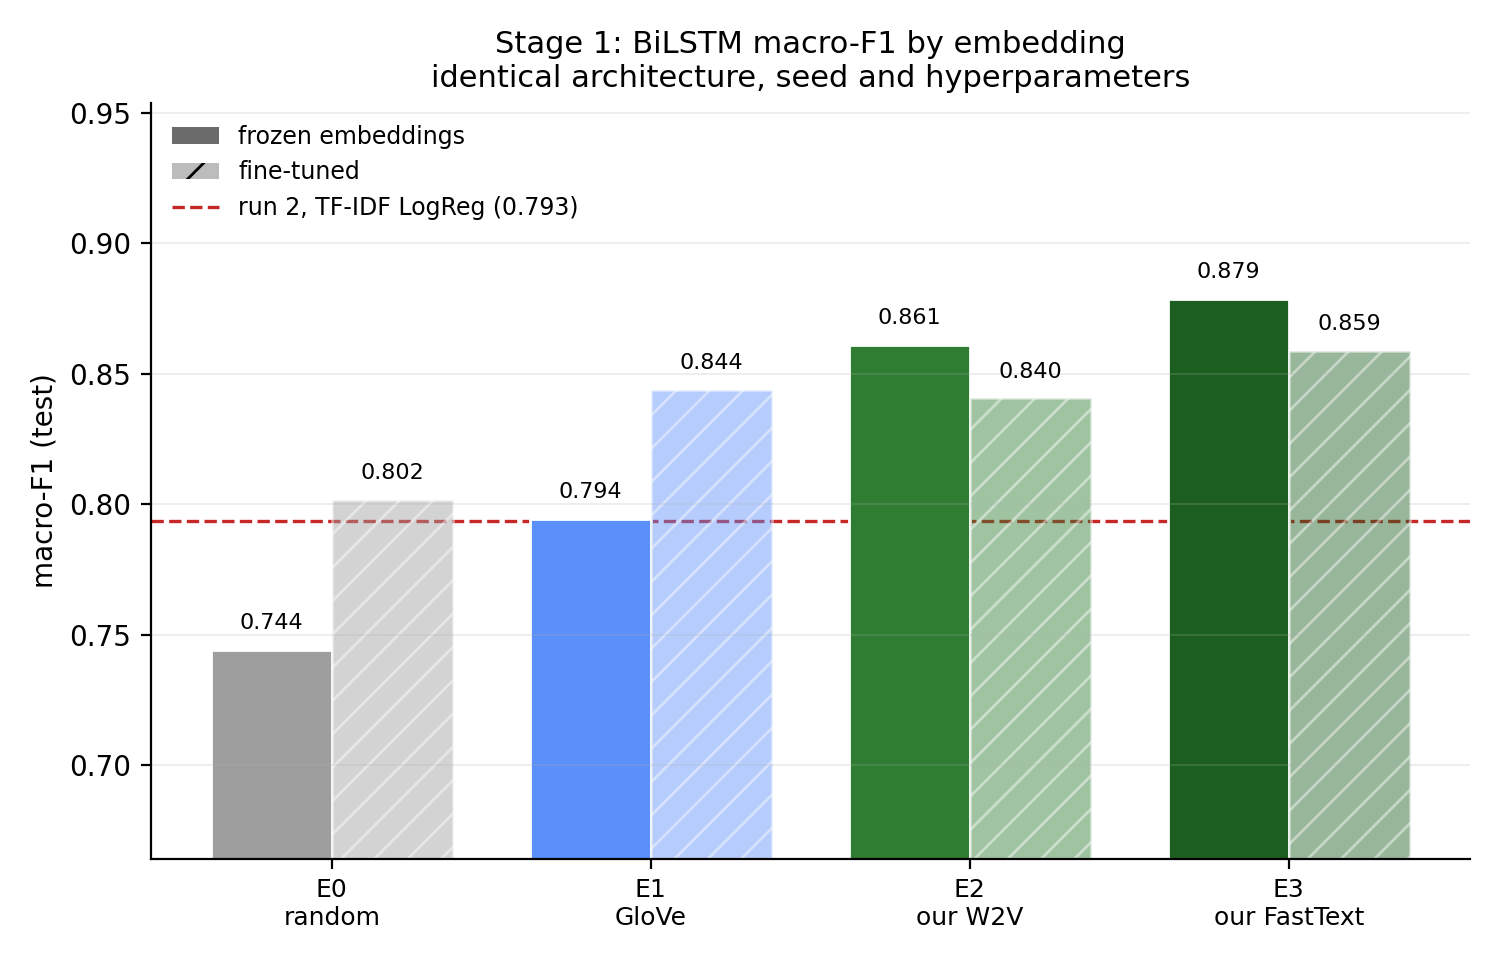

In [6]:
from IPython.display import Image
Image(filename=str(ROOT / "results" / "figures" / "stage1_embeddings.png"))

**0.744 → 0.879.** That climb is the project's result.

Read it in three steps:

1. **E0 → E1 (+0.050).** General-purpose English vectors help. Knowing that *the*, *after*
   and *patient* are words is worth something.
2. **E1 → E2 (+0.067).** Training on 159,975 medical abstracts instead of Wikipedia helps
   *more than having vectors at all did*. This is the finding.
3. **E2 → E3 (+0.018).** FastText's character n-grams add a bit on top, consistent with
   notebook 3: it handles the morphological variants of drug names that Word2Vec treats as
   unrelated words.

The dashed line on the chart is run 2, TF-IDF logistic regression. It is there on purpose:
a BiLSTM *below* it would mean the network is undertrained, and you can see that at a
glance instead of having to cross-reference a table. E0 sits below it — a BiLSTM with no
word knowledge does worse than bag-of-words. That is the ablation working correctly.

### Frozen vs fine-tuned: a result that goes the other way

Every ablation run was repeated with the embedding layer *unfrozen*, so the task could
update the vectors. Those are the runs with a `u` suffix. The two conditions answer
different questions:

- **Frozen** — how good are these vectors?
- **Fine-tuned** — does that advantage survive once the task has had its say?

In [7]:
compare = pd.DataFrame({
    "embedding": ["E0 random", "E1 GloVe", "E2 Word2Vec", "E3 FastText"],
    "frozen": [table.loc[r, "macro-F1 (test)"] for r in ["3", "4", "5", "6"]],
    "fine-tuned": [table.loc[r, "macro-F1 (test)"] for r in ["3u", "4u", "5u", "6u"]],
})
compare["change"] = (compare["fine-tuned"] - compare["frozen"]).round(4)
compare["fine-tuning"] = compare["change"].map(lambda d: "helped" if d > 0 else "hurt")
compare

,embedding,frozen,fine-tuned,change,fine-tuning
0,E0 random,0.7441,0.8016,0.0575,helped
1,E1 GloVe,0.7942,0.8436,0.0494,helped
2,E2 Word2Vec,0.8609,0.8404,-0.0205,hurt
3,E3 FastText,0.8785,0.8587,-0.0198,hurt


**Fine-tuning helped the weak embeddings and hurt the good ones.** The effect reverses with
the quality of the starting vectors.

That is what a small training set predicts: 14,628 sentences carry enough signal to improve
random or general-purpose vectors, but not enough to improve vectors already trained on
159,975 biomedical abstracts. Updating those mostly discards information.

And note where it leaves the ordering: the best fine-tuned run reaches 0.8587 — still below
the *weakest frozen* domain run at 0.8609. Task supervision does not close the gap. That is
the stronger version of the claim, because it says the advantage lives in the vectors
themselves rather than in the head start they provide.

### The transformers

| Run | Model | Macro-F1 | Pretrained on |
|---|---|---|---|
| 7 | `bert-base-uncased` | 0.9159 | general English |
| 8 | **BiomedBERT** | **0.9402** | PubMed abstracts |

The same pattern one tier up: the domain-pretrained model wins by 0.024. Run 8 is the best
Stage 1 model in the project, and it is the gate used for the end-to-end pipeline in
notebook 6.

---

## 4.4 Running the saved model

Nothing above is retrained here. The checkpoints are in `models/stage1/`, and the cell
below loads run 6 and scores it on the test split — on this laptop's CPU, in a couple of
seconds.

In [8]:
import time
from sklearn.metrics import classification_report, f1_score
from src.pipeline import BiLSTMGate

t0 = time.perf_counter()
gate = BiLSTMGate(ROOT / "models" / "stage1" / "run6_E3" / "checkpoint.pt")
print(f"checkpoint loaded in {time.perf_counter() - t0:.1f}s")

t0 = time.perf_counter()
predictions = [int(is_ade) for _, is_ade in gate.classify(test["text"].tolist())]
print(f"{len(test):,} sentences classified in {time.perf_counter() - t0:.1f}s\n")

print(classification_report(test["label"], predictions, target_names=["not ADE", "ADE"],
                            digits=4))
print(f"macro-F1: {f1_score(test['label'], predictions, average='macro'):.4f}"
      f"   (logged for run 6: {table.loc['6', 'macro-F1 (test)']})")

checkpoint loaded in 0.0s


3,133 sentences classified in 2.4s

              precision    recall  f1-score   support

     not ADE     0.9521    0.9479    0.9499      2493
         ADE     0.8003    0.8141    0.8071       640

    accuracy                         0.9205      3133
   macro avg     0.8762    0.8810    0.8785      3133
weighted avg     0.9211    0.9205    0.9208      3133

macro-F1: 0.8785   (logged for run 6: 0.8785)


The number matches the logged one exactly — the checkpoint on this laptop is the same model
that ran on the GPU.

The per-class breakdown shows where the difficulty is. Precision and recall on `not ADE` are
both around 0.95; on `ADE` they are around 0.80. The minority class is harder, which is
exactly why macro-F1 is the metric and accuracy is not.

In [9]:
for sentence in ["A case of toxic hepatitis caused by methotrexate.",
                 "The patient was treated with cisplatin, vinblastine and bleomycin.",
                 "No adverse reaction to the vaccine was observed.",
                 "Severe rhabdomyolysis developed after starting simvastatin."]:
    p_ade, is_ade = gate.classify([sentence])[0]
    print(f"{'ADE    ' if is_ade else 'not ADE'}  p={p_ade:.3f}   {sentence}")

ADE      p=0.983   A case of toxic hepatitis caused by methotrexate.
not ADE  p=0.038   The patient was treated with cisplatin, vinblastine and bleomycin.
not ADE  p=0.004   No adverse reaction to the vaccine was observed.
ADE      p=0.989   Severe rhabdomyolysis developed after starting simvastatin.


---

## What this notebook produced

| Artefact | Contents |
|---|---|
| `models/stage1/run{1..8}*/` | eight trained Stage 1 models |
| `results/runs.csv` | one row per run: score, hyperparameters, git commit, seed |
| `results/figures/stage1_embeddings.png` | the ablation chart |

**Key numbers:** ablation 0.744 → 0.879 macro-F1; best overall BiomedBERT at 0.940.

**Next:** [5 — Stage 2](05_stage2_tagging.ipynb), which finds the drug and the effect inside
the sentences Stage 1 accepts.